In [1]:
import osmnx as ox
import networkx as nx

In [7]:
CU = ox.geocode_to_gdf(['Champaign, Illinois, USA', 'Urbana, Illinois, USA'])

In [8]:
places = [
    "Champaign, Illinois, USA",
    "Urbana, Illinois, USA"
]
gdf = ox.geocode_to_gdf(places)

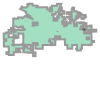

In [9]:
gdf.unary_union

In [10]:
G1 = ox.graph_from_polygon(gdf['geometry'][1], network_type="walk")
G0 = ox.graph_from_polygon(gdf['geometry'][0], network_type="walk")

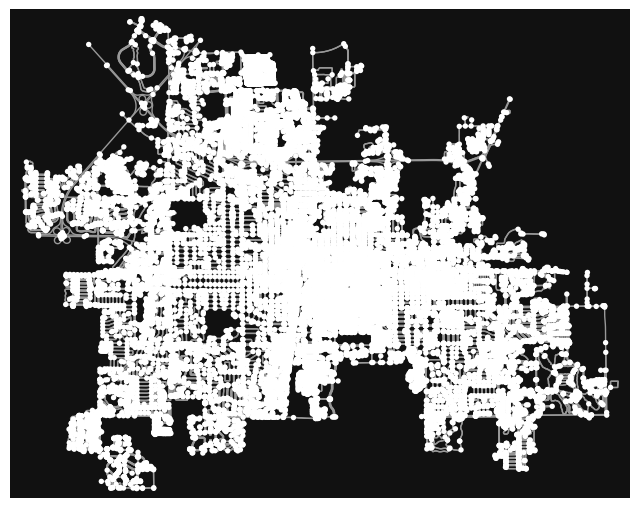

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph(ox.graph_from_polygon(gdf.unary_union))

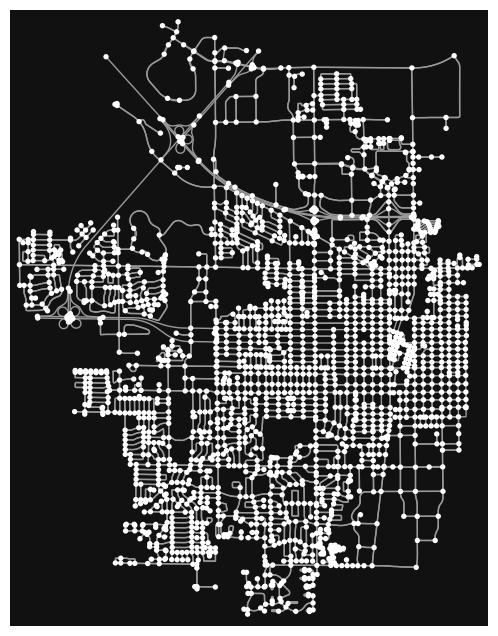

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
import osmnx as ox

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')

ox.plot_graph(champaign)

In [24]:
import json

'''nodes = champaign.nodes

for i,node in enumerate(nodes):
    if not i:
        print(node)
        views = [view for view in champaign[node].values()]
        for view in views:
            print(view[0]['name'])'''

edges = champaign.edges

for i, edge in enumerate(edges):
    if not i:
        print(edge)
        print(champaign[edge[0]][edge[1]])
        #print(champaign[edge[1]])

(37945137, 38032634, 0)
{0: {'osmid': 237756215, 'oneway': True, 'name': 'West University Avenue', 'highway': 'primary', 'maxspeed': '30 mph', 'reversed': False, 'length': 141.592}}


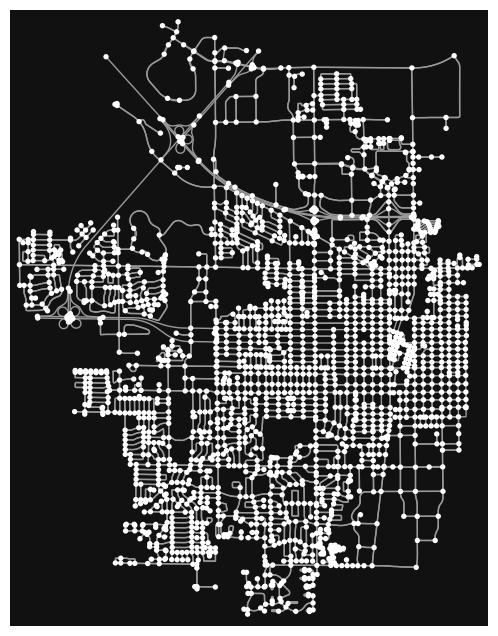

In [17]:
import os
import sys
import osmnx as ox

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')

ox.plot_graph(champaign)

from utils import node_from_address

starting_node = node_from_address(champaign, '1008 S 4th Street, Champaign, IL')
final_node = node_from_address(champaign, '2610 N Prospect Ave, Champaign, IL')

In [20]:
import networkx as nx
import numpy as np

for i, node in enumerate(champaign.nodes):
    if node == starting_node:
        start_idx = i
    elif node == final_node:
        final_idx = i
        
print(start_idx, final_idx)

1492 1964


In [35]:
import gurobipy as gp
from gurobipy import GRB

G = nx.DiGraph(champaign)

A = nx.incidence_matrix(G, oriented=True)

b = np.zeros(G.number_of_nodes())

b[start_idx] = -1
b[final_idx] = 1

f = np.zeros(G.number_of_edges())

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=G.number_of_edges(), vtype=GRB.CONTINUOUS, lb=0, name="")

m.addConstr(A@f==b)
obj = np.ones(G.number_of_edges())@f
m.setObjective(obj, GRB.MINIMIZE)
m.optimize()

flows = m.getAttr("X", m.getVars())

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
        if flows[i]==1:
            flowed_edges_idx += [i]

for i, edge in enumerate(champaign.edges):
    if i in flowed_edges_idx:
        flowed_edges += [edge]
    
print(flowed_edges)

[(37945299, 38092893, 0), (37963660, 37955130, 0), (37978381, 37978400, 0), (37982606, 38024373, 0), (37982606, 37982597, 0), (37982611, 37982610, 0), (37982619, 2464796085, 0), (37982901, 37982911, 0), (37982911, 37982915, 0), (37982911, 38127672, 0), (37982915, 38127672, 0), (37982918, 38107786, 0), (37982921, 38140494, 0), (38019150, 38019152, 0), (38019312, 37977234, 0), (38019337, 38019339, 0), (38019339, 38019340, 0), (38019340, 38019339, 0), (38022931, 38022922, 0), (38026298, 38047403, 0), (38033550, 38073351, 0), (38046350, 38093814, 0), (38072875, 38129382, 0), (38072948, 38101180, 0), (38085291, 38052135, 0), (38086863, 37990346, 0), (38090995, 38090998, 0), (38090995, 38027615, 0), (38090998, 37945290, 0), (38091002, 7413852382, 0), (38091020, 38091048, 0), (38091048, 38072893, 0), (38124756, 38050120, 0), (38128333, 2192255117, 0), (38134515, 38134490, 0), (38138646, 38068460, 0), (38153359, 38128622, 0), (2454764998, 37977501, 0), (2457410419, 38009160, 0), (6563450916, 3

True
41


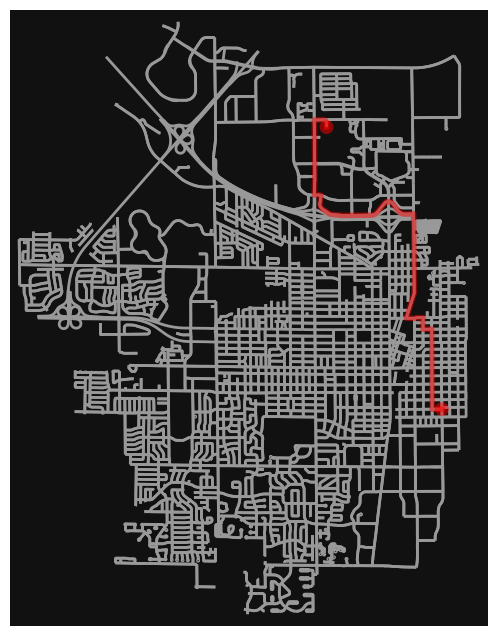

In [57]:
print(nx.has_path(nx.DiGraph(champaign), starting_node, final_node))

route = nx.shortest_path(champaign, starting_node, final_node)

flowed_edges = []

route_length = len(route)
print(route_length)

for i in range(route_length-1):
    flowed_edges += [(route[i], route[i+1])]

fig, ax = ox.plot_graph_route(champaign, route, node_color='w', node_edgecolor='k', node_size=0, 
                           node_zorder=3, edge_linewidth=2)


In [76]:
for node in nodes:
    info = champaign[node]
    s_4th = 0
    e_arm = 0
    for connecting_node in info:
        if not 'name' in champaign[node][connecting_node][0]:
            continue #== 'South Fourth Street':
        if champaign[node][connecting_node][0]['name'] == 'South Fourth Street' :
            s_4th = 1
        if champaign[node][connecting_node][0]['name'] == 'East Armory Avenue':
            e_arm = 1
        if s_4th + e_arm >= 2:
            print(champaign[node])
            #print(champaign[node], champaign[connecting_node])
        #print(1)

{37975592: {0: {'osmid': 5327716, 'oneway': False, 'lanes': '2', 'name': 'East Armory Avenue', 'highway': 'residential', 'reversed': True, 'length': 89.049, 'geometry': <LINESTRING (-88.233 40.105, -88.234 40.105, -88.234 40.105, -88.234 40.105,...>}}, 37975595: {0: {'osmid': 729125683, 'oneway': False, 'lanes': '2', 'name': 'East Armory Avenue', 'highway': 'unclassified', 'reversed': False, 'length': 127.323, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.105, -88.232 40.105)>}}, 38059714: {0: {'osmid': 729125684, 'name': 'South Fourth Street', 'highway': 'tertiary', 'maxspeed': '25 mph', 'oneway': False, 'reversed': False, 'length': 144.637, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.105, -88.233 40.105, -88.233 40.105,...>}}, 38089239: {0: {'osmid': 745436740, 'name': 'South Fourth Street', 'highway': 'tertiary', 'maxspeed': '25 mph', 'oneway': False, 'reversed': True, 'length': 129.005, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.106, -88.233 40.106, -88.233 4